# import experimental data

In [1]:
from utils import *
NOTEBOOK_ID = '08'

In [2]:
data_df = pd.read_csv(f'{ANALYSIS_DIR}/experimental_data_fitted.csv')
activator_df = data_df.query('is_activator == True')
library_df = pd.read_csv(f'{LIBRARY_DIR}/viral_library.csv')
protein_df = pd.read_csv(f'{TILE_DIR}/viral_proteins_clustered90.csv')

cols = ['query','seed_ortholog','evalue','score','eggNOG_OGs','max_annot_lvl','COG_category','Description','Preferred_name','GOs','EC','KEGG_ko','KEGG_Pathway','KEGG_Module','KEGG_Reaction','KEGG_rclass','BRITE','KEGG_TC','CAZy','BiGG_Reaction','PFAMs']
eggnog_df = pd.read_csv(f'{ANALYSIS_DIR}/eggnog_mapper_results.tsv',sep='\t',comment='#',names=cols)
eggnog_df = eggnog_df.replace('-',np.nan).dropna(axis=1, how='all')
tiles_df = pd.read_csv(f'{TILE_DIR}/viral_tiles.csv')

MAKE_FASTA = False
if MAKE_FASTA:
    with open(f'{ANALYSIS_DIR}/activators.faa','w') as out_file:
        for idx,row in activator_df.drop_duplicates('tile').iterrows():
            out_file.write(f'>{row["tile_ID"]}\n{row["tile"]}\n')

# find motifs

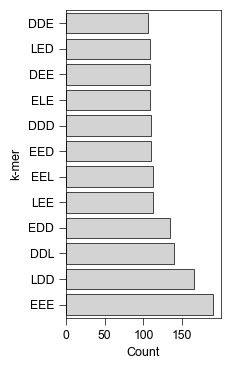

In [3]:
result = find_motifs(list(activator_df['tile'].unique()),k=3)
kmer_df = pd.DataFrame(result).fillna(0.0).T.sum().reset_index()
kmer_df.columns = ['kmer','count']

plt.figure(figsize=(2,4))
g = sns.barplot(data=kmer_df.sort_values('count').query('count > 100'),x='count',y='kmer',color='lightgrey',edgecolor='black',linewidth=0.5)
g.set(xlabel='Count',ylabel='k-mer',ymargin=0.01)

if SAVE_FIGURES:
    plt.savefig(f'{FIGURE_DIR}/{NOTEBOOK_ID}-library_3mers.svg',**FIG_PARAMS)

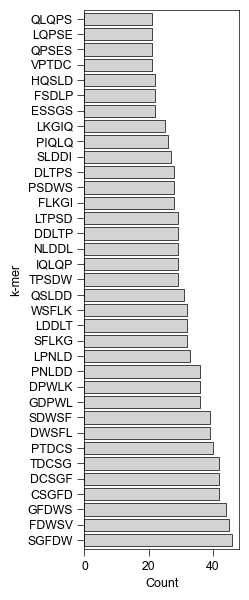

In [4]:
result = find_motifs(list(activator_df['tile'].unique()),k=5)
kmer_df = pd.DataFrame(result).fillna(0.0).T.sum().reset_index()
kmer_df.columns = ['motif','count']

plt.figure(figsize=(2,7))
g = sns.barplot(data=kmer_df.sort_values('count').query('count > 20'),x='count',y='motif',color='lightgrey',edgecolor='black',linewidth=0.5)
g.set(xlabel='Count',ylabel='k-mer',ymargin=0.005)

if SAVE_FIGURES:
    plt.savefig(f'{FIGURE_DIR}/{NOTEBOOK_ID}-library_5mers.svg',**FIG_PARAMS)

# compare to known motifs

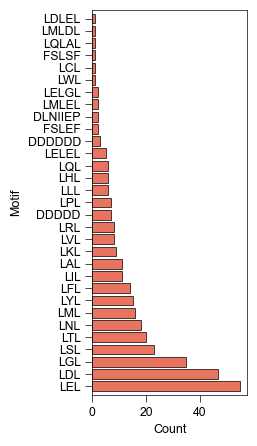

In [5]:
relaxed_motifs_df = pd.read_csv(f'{METADATA_DIR}/relaxed_plant_repression_motifs.csv').drop(columns=['Unnamed: 0']).drop_duplicates()
relaxed_motifs_df['Library'] = relaxed_motifs_df['0'].apply(lambda x: lookup_motif(x, data_df['tile'].unique()))
relaxed_motifs_df['Activator'] = relaxed_motifs_df['0'].apply(lambda x: lookup_motif(x, activator_df['tile'].unique()))
tmp_df = relaxed_motifs_df.query('Activator > 0').melt(id_vars='0',value_vars='Activator')

plt.figure(figsize=(2,5))
g = sns.barplot(data=tmp_df.sort_values('value'),y='0',x='value',color='tomato',edgecolor='black',linewidth=0.5)
g.set(xlabel='Count',ylabel='Motif',ymargin=0.01)

if SAVE_FIGURES:
    plt.savefig(f'{FIGURE_DIR}/{NOTEBOOK_ID}-activators_relaxed_motifs.svg',**FIG_PARAMS)

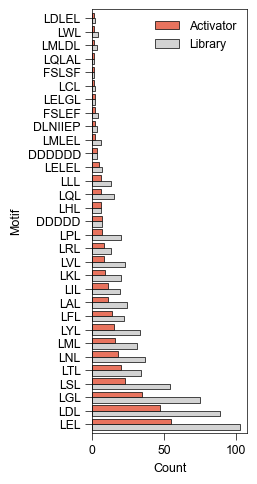

In [6]:
tmp_df = relaxed_motifs_df.query('Activator > 0 and Library > 0').melt(id_vars='0',value_vars=['Activator','Library'])
plt.figure(figsize=(2,5.5))
g = sns.barplot(data=tmp_df.sort_values('value'),y='0',x='value',hue='variable',palette=['tomato','lightgrey'],edgecolor='black',linewidth=0.5)
g.legend(frameon=False)
g.set(xlabel='Count',ylabel='Motif',ymargin=0.0075)

if SAVE_FIGURES:
    plt.savefig(f'{FIGURE_DIR}/{NOTEBOOK_ID}-relaxed_motifs.svg',**FIG_PARAMS)

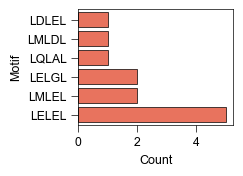

In [7]:
stringent_motifs_df = pd.read_csv(f'{METADATA_DIR}/stringent_plant_repression_motifs.csv').drop(columns=['Unnamed: 0']).drop_duplicates()
stringent_motifs_df['Library'] = stringent_motifs_df['0'].apply(lambda x: lookup_motif(x, data_df['tile'].unique()))
stringent_motifs_df['Activator'] = stringent_motifs_df['0'].apply(lambda x: lookup_motif(x, activator_df['tile'].unique()))
tmp_df = stringent_motifs_df.query('Activator > 0').melt(id_vars='0',value_vars='Activator')

plt.figure(figsize=(2,1.5))
g = sns.barplot(data=tmp_df.sort_values('value'),y='0',x='value',color='tomato',edgecolor='black',linewidth=0.5)
g.set(xlabel='Count',ylabel='Motif',ymargin=0.025);

if SAVE_FIGURES:
    plt.savefig(f'{FIGURE_DIR}/{NOTEBOOK_ID}-activators_stringent_motifs.svg',**FIG_PARAMS)

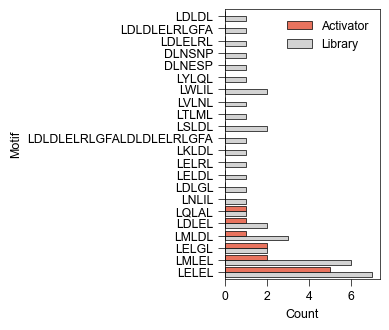

In [8]:
tmp_df = stringent_motifs_df.query('Activator > 0 or Library > 0').melt(id_vars='0',value_vars=['Activator','Library'])
plt.figure(figsize=(2,3.5))
g = sns.barplot(data=tmp_df.sort_values('value'),y='0',x='value',hue='variable',palette=['tomato','lightgrey'],edgecolor='black',linewidth=0.5)
g.set(xlabel='Count',ylabel='Motif',ymargin=0.0075)
g.legend(frameon=False)

if SAVE_FIGURES:
    plt.savefig(f'{FIGURE_DIR}/{NOTEBOOK_ID}-stringent_motifs.svg',**FIG_PARAMS)